# import the data

In [5]:
import pandas as pd
import numpy as np


In [6]:
data = pd.read_csv('Epileptic Seizure Recognition.csv')

In [6]:
data = pd.read_csv('Epileptic Seizure Recognition.csv')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), object(1)
memory usage: 15.8+ MB


In [8]:
data.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


# Data visualization

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

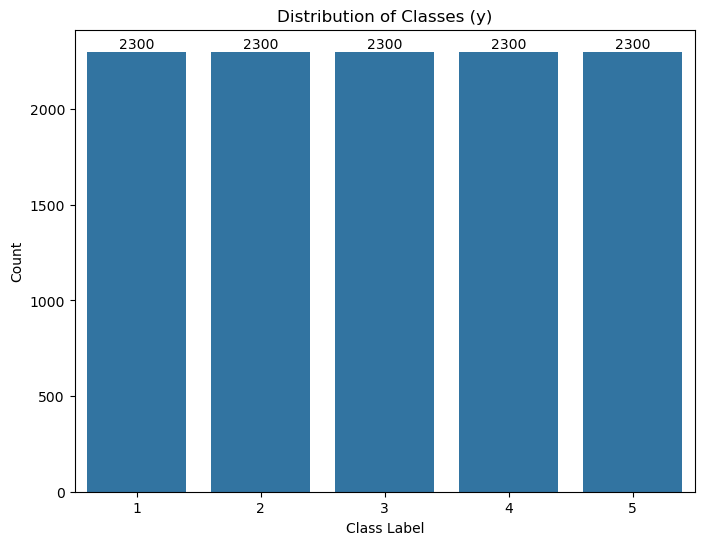

In [10]:

plt.figure(figsize=(8,6))
ax = sns.countplot(x='y', data=data)
plt.title('Distribution of Classes (y)')
plt.xlabel('Class Label')
plt.ylabel('Count')

# Add numeric values on top of each bar
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count}', 
                (p.get_x() + p.get_width() / 2., count), 
                ha='center', va='bottom', fontsize=10)

plt.show()


In [11]:
corr = data.iloc[:, 1:-1].corr()

# Show the first few rows for readability
print(corr.head())
corr.style.background_gradient(cmap='vlag').format("{:.2f}")

          X1        X2        X3        X4        X5        X6        X7  \
X1  1.000000  0.947729  0.808192  0.608109  0.393674  0.218226  0.103693   
X2  0.947729  1.000000  0.944623  0.790403  0.576579  0.369803  0.211793   
X3  0.808192  0.944623  1.000000  0.939522  0.778648  0.573874  0.382493   
X4  0.608109  0.790403  0.939522  1.000000  0.938636  0.784954  0.590497   
X5  0.393674  0.576579  0.778648  0.938636  1.000000  0.941267  0.792304   

          X8        X9       X10  ...      X169      X170      X171      X172  \
X1  0.044483  0.027923  0.032221  ...  0.006206  0.027263  0.045401  0.051630   
X2  0.109478  0.060218  0.043565  ... -0.001270  0.012602  0.025937  0.031606   
X3  0.231084  0.133249  0.080003  ... -0.002198  0.004575  0.011752  0.016424   
X4  0.399855  0.250052  0.150284  ... -0.000491 -0.001028  0.000632  0.006617   
X5  0.596424  0.410651  0.265112  ...  0.011613  0.004861  0.000918  0.006488   

        X173      X174      X175      X176      X177    

In [12]:
threshold = 0.8  # show only strong correlations
strong_corr = corr[(corr >= threshold) | (corr <= -threshold)]

# Print the filtered correlations
print(strong_corr.dropna(how='all').dropna(axis=1, how='all'))


            X1        X2        X3        X4        X5        X6  X7  X8  X9  \
X1    1.000000  0.947729  0.808192       NaN       NaN       NaN NaN NaN NaN   
X2    0.947729  1.000000  0.944623       NaN       NaN       NaN NaN NaN NaN   
X3    0.808192  0.944623  1.000000  0.939522       NaN       NaN NaN NaN NaN   
X4         NaN       NaN  0.939522  1.000000  0.938636       NaN NaN NaN NaN   
X5         NaN       NaN       NaN  0.938636  1.000000  0.941267 NaN NaN NaN   
...        ...       ...       ...       ...       ...       ...  ..  ..  ..   
X174       NaN       NaN       NaN       NaN       NaN       NaN NaN NaN NaN   
X175       NaN       NaN       NaN       NaN       NaN       NaN NaN NaN NaN   
X176       NaN       NaN       NaN       NaN       NaN       NaN NaN NaN NaN   
X177       NaN       NaN       NaN       NaN       NaN       NaN NaN NaN NaN   
X178       NaN       NaN       NaN       NaN       NaN       NaN NaN NaN NaN   

      X10  ...  X169  X170  X171  X172 

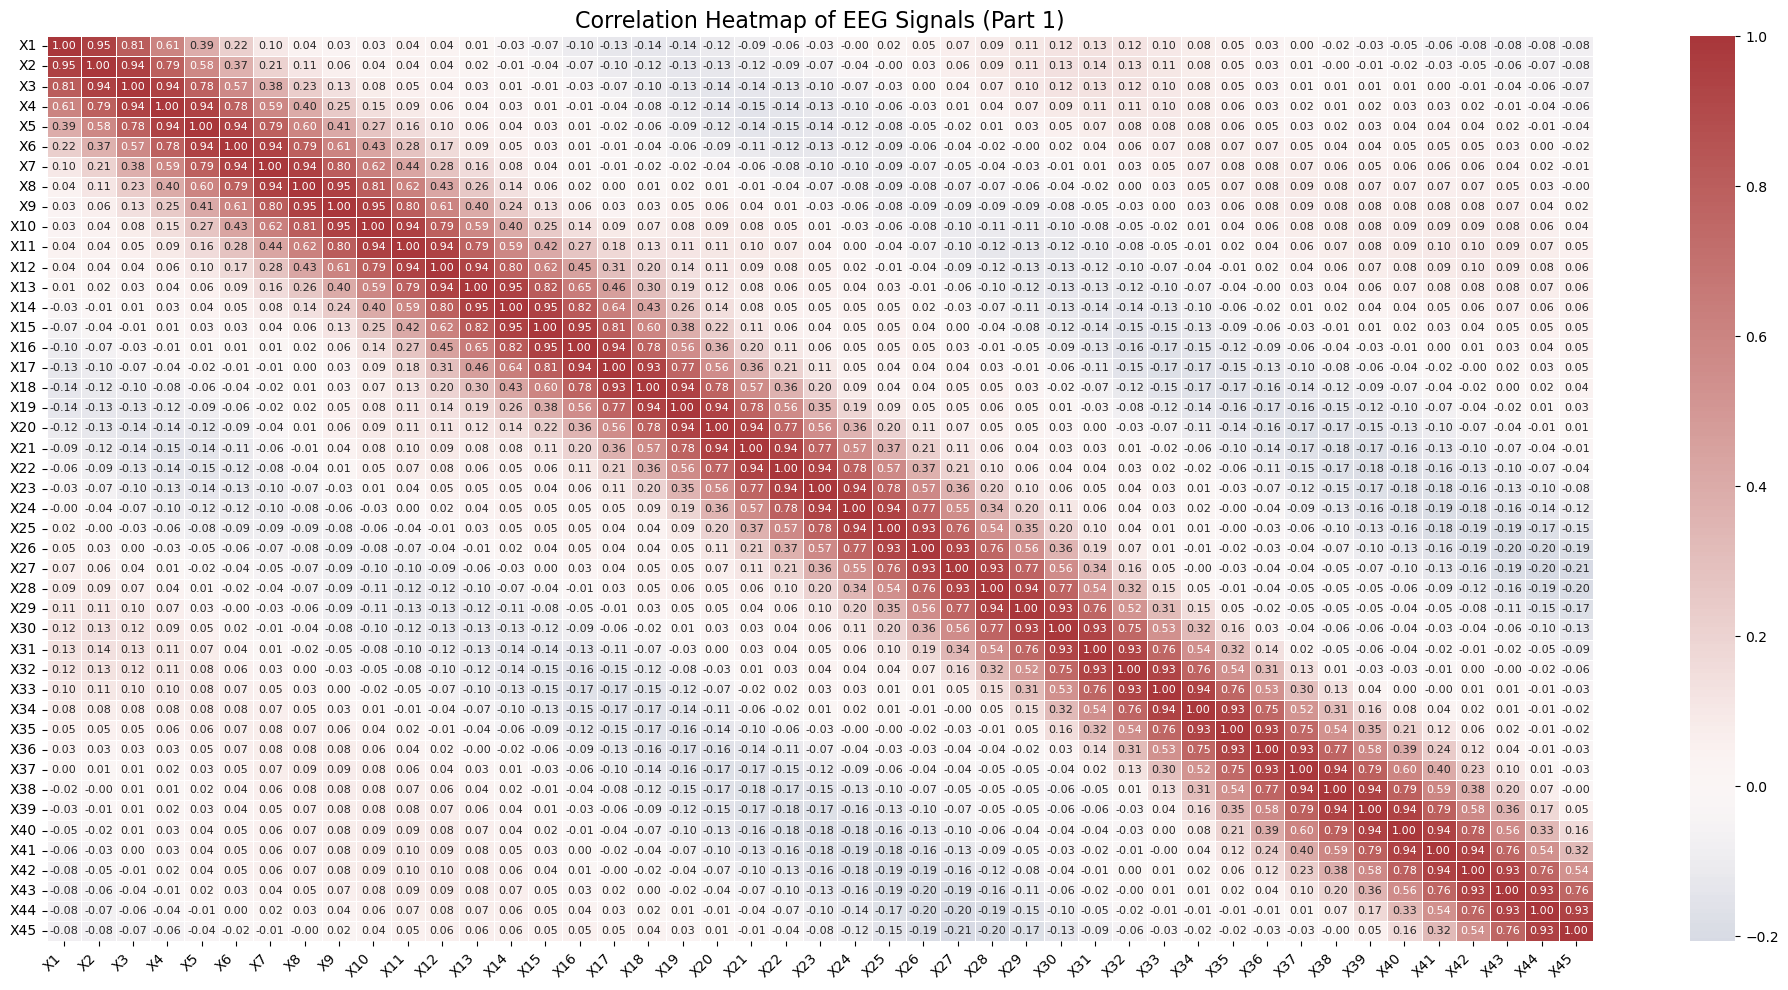

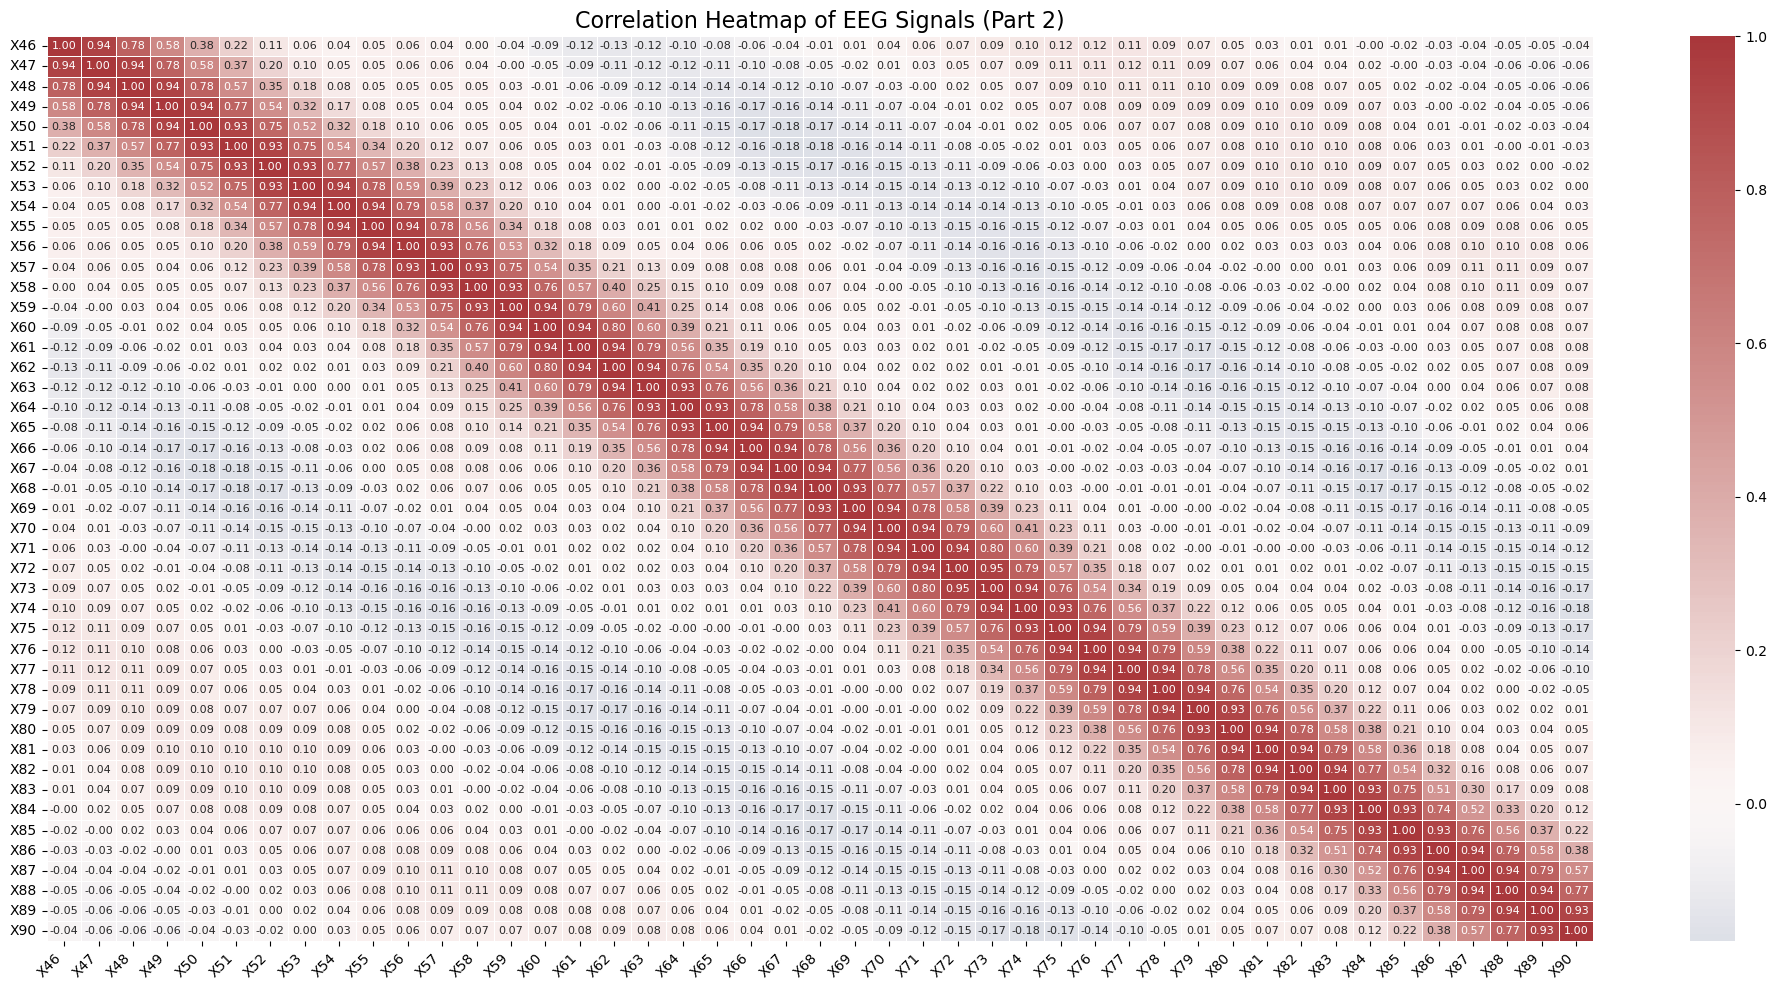

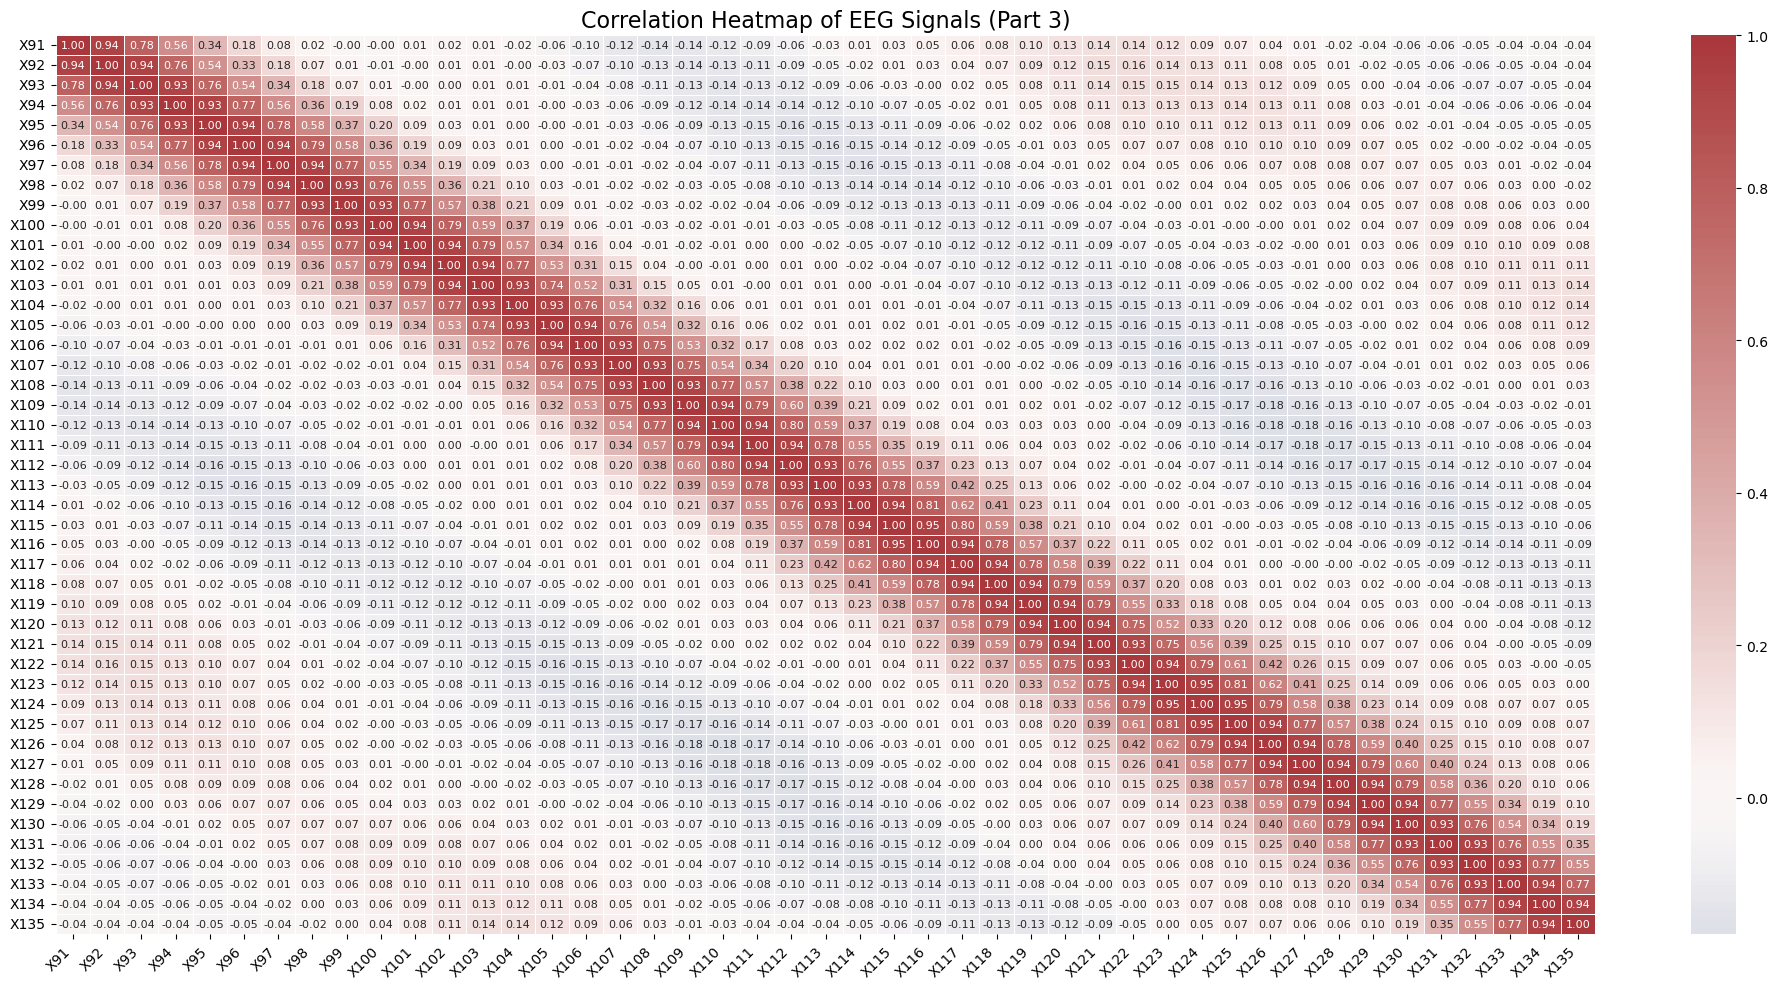

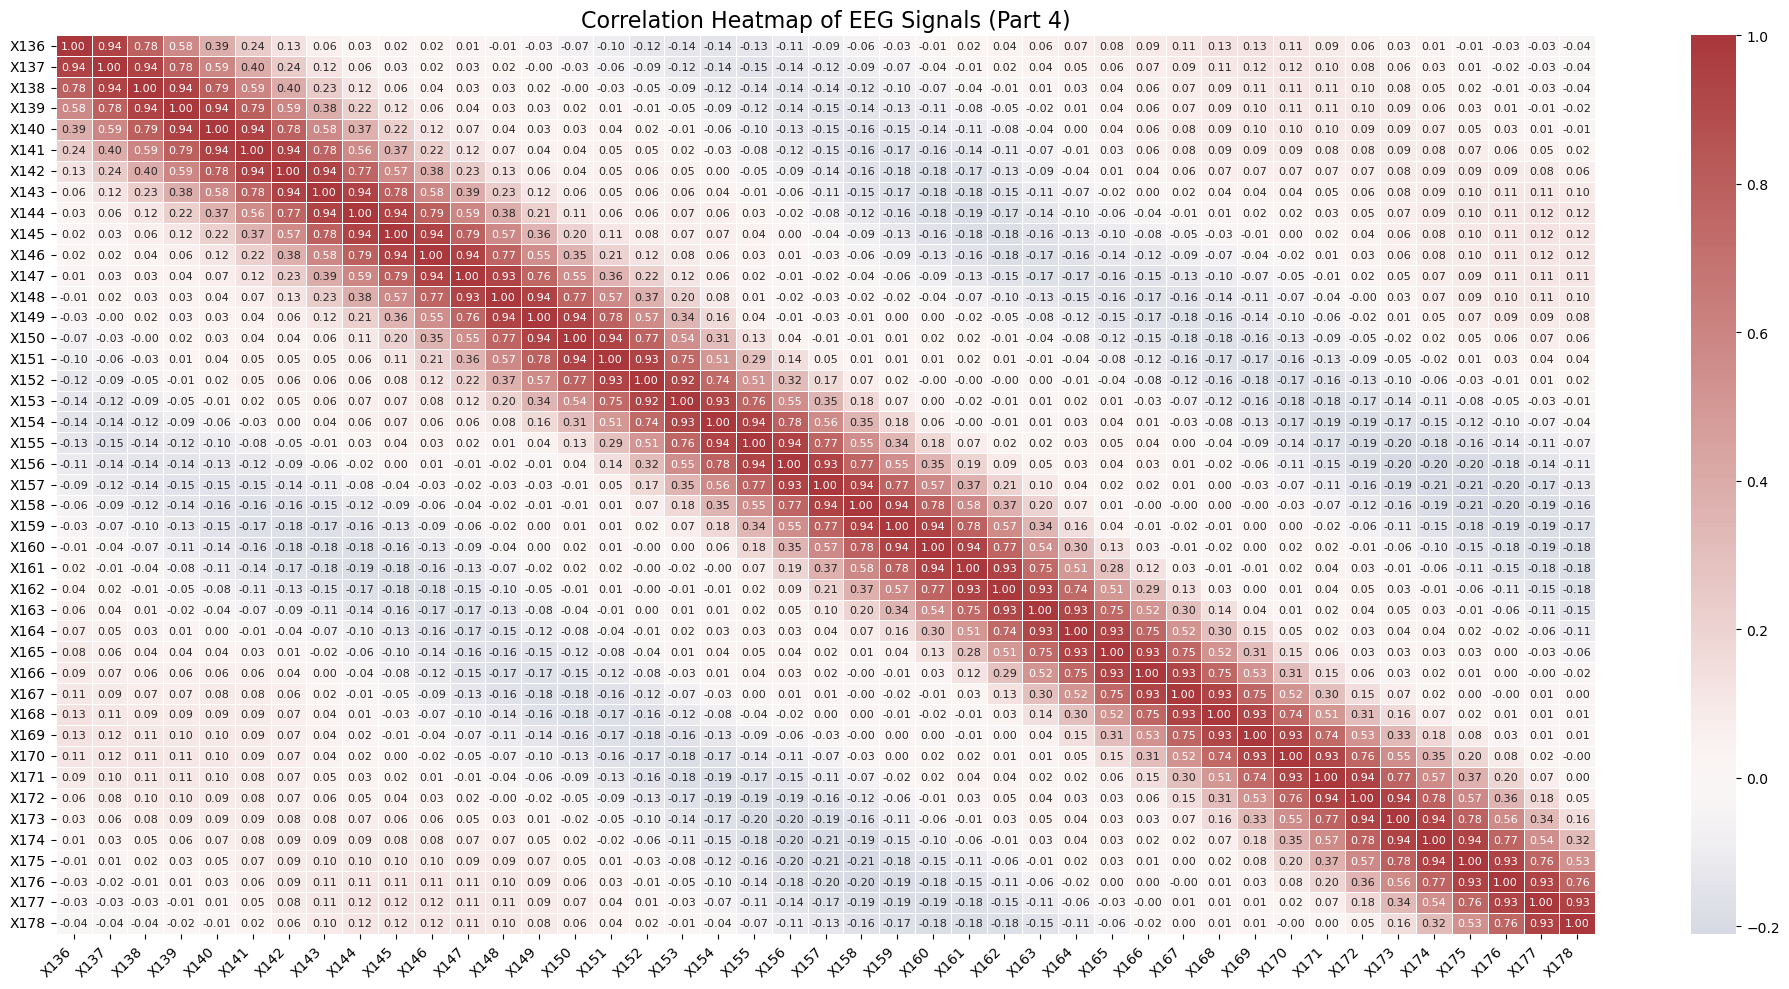

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr = data.iloc[:, 1:-1].corr()
features = corr.columns
n = len(features)

# Define how many parts we want
num_parts = 4
step = n // num_parts + 1  # ensures all columns are covered

# Plot each part with larger x-axis
for i in range(num_parts):
    start = i * step
    end = min((i + 1) * step, n)
    subset_features = features[start:end]
    
    plt.figure(figsize=(20,10))  # Wider figure for larger x-axis
    sns.heatmap(corr.loc[subset_features, subset_features], 
                cmap='vlag', center=0, annot=True, fmt=".2f", linewidths=0.5,
                annot_kws={"size": 8})  # Adjust annotation size if needed
    
    plt.title(f'Correlation Heatmap of EEG Signals (Part {i+1})', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()


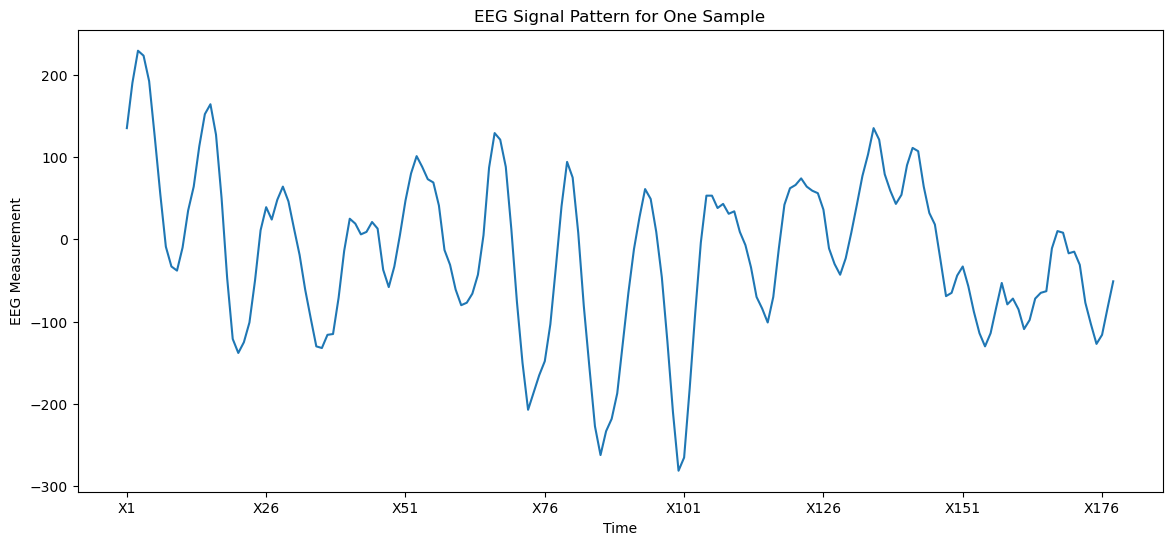

In [14]:
plt.figure(figsize=(14,6))
sample = data.iloc[0, 1:-1]
sample.plot()
plt.title('EEG Signal Pattern for One Sample')
plt.xlabel('Time')
plt.ylabel('EEG Measurement')
plt.show()

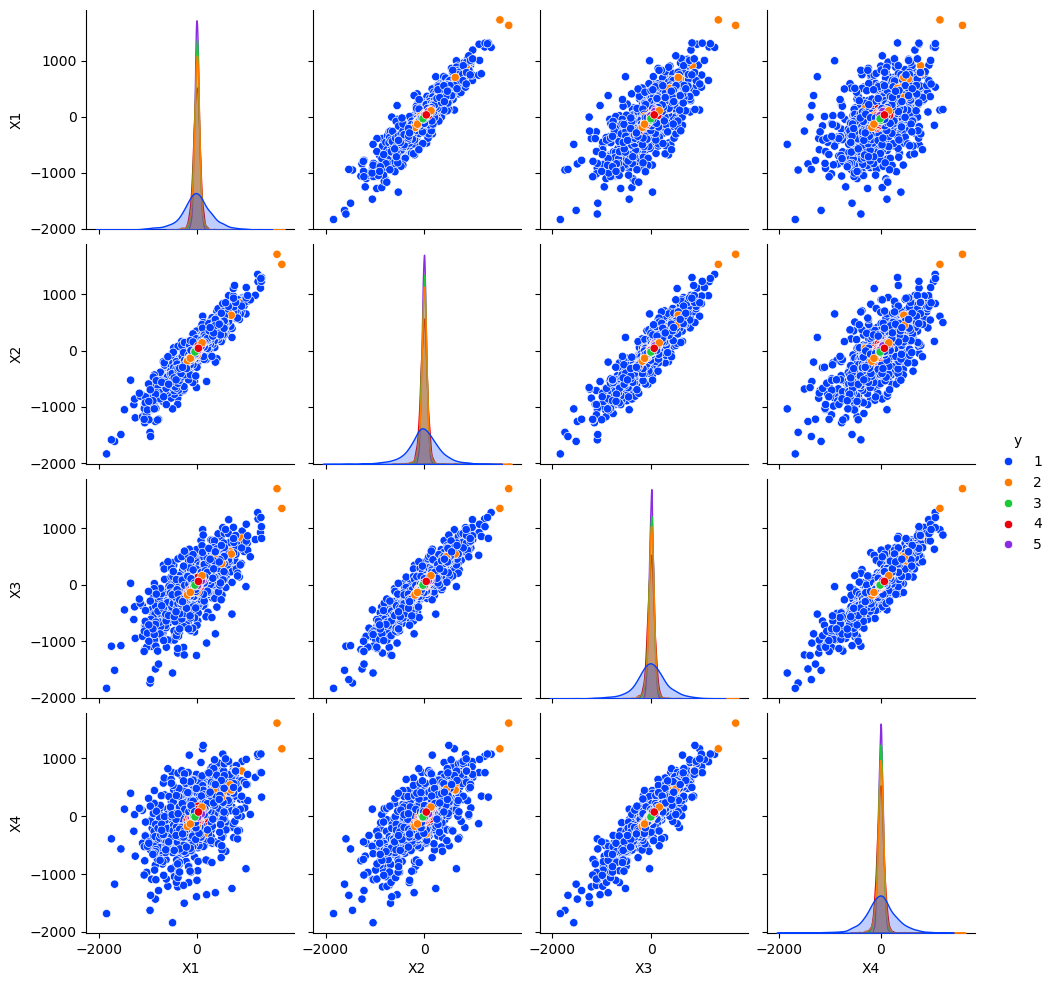

In [15]:
selected_cols = ['X1', 'X2', 'X3', 'X4', 'y']
sns.pairplot(data[selected_cols], hue='y', palette='bright')
plt.show()


#  Data preprocessing 

In [16]:
# Check if any value is missing
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])


Series([], dtype: int64)


In [17]:
import pandas as pd

# Show data types of each column
print("Column Data Types:")
print(data.dtypes)

# Check for missing values in each column
print("\nMissing Values in Each Column:")
print(data.isnull().sum())

# Check for duplicate rows
print("\nNumber of Duplicate Rows:")
print(data.duplicated().sum())


Column Data Types:
Unnamed    object
X1          int64
X2          int64
X3          int64
X4          int64
            ...  
X175        int64
X176        int64
X177        int64
X178        int64
y           int64
Length: 180, dtype: object

Missing Values in Each Column:
Unnamed    0
X1         0
X2         0
X3         0
X4         0
          ..
X175       0
X176       0
X177       0
X178       0
y          0
Length: 180, dtype: int64

Number of Duplicate Rows:
0


In [18]:
X = data.iloc[:, 1:-1]  # All EEG columns except ID and target
y = data['y']            # Target column


In [19]:
X

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
0,135,190,229,223,192,125,55,-9,-33,-38,...,8,-17,-15,-31,-77,-103,-127,-116,-83,-51
1,386,382,356,331,320,315,307,272,244,232,...,168,164,150,146,152,157,156,154,143,129
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,29,57,64,48,19,-12,-30,-35,-35,-36
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,10,4,2,-12,-32,-41,-65,-83,-89,-73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,-22,-22,-23,-26,-36,-42,-45,-42,-45,-49,...,20,15,16,12,5,-1,-18,-37,-47,-48
11496,-47,-11,28,77,141,211,246,240,193,136,...,-94,-65,-33,-7,14,27,48,77,117,170
11497,14,6,-13,-16,10,26,27,-9,4,14,...,-42,-65,-48,-61,-62,-67,-30,-2,-1,-8
11498,-40,-25,-9,-12,-2,12,7,19,22,29,...,114,121,135,148,143,116,86,68,59,55


In [20]:
y

0        4
1        1
2        5
3        5
4        5
        ..
11495    2
11496    1
11497    5
11498    3
11499    4
Name: y, Length: 11500, dtype: int64

# Feature Scaling (Standardization)

In [21]:
# Different features have different units and ranges, which can affect model training.

# StandardScaler scales features to have:
# ✔ A mean of 0
# ✔ A standard deviation of 1 

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [23]:
X_scaled

array([[ 0.88505134,  1.20992878,  1.46276429, ..., -0.63414367,
        -0.43329036, -0.23539922],
       [ 2.40057718,  2.36619038,  2.23944096, ...,  1.02342937,
         0.95424076,  0.85653664],
       [-0.12328657, -0.16915405, -0.22513147, ..., -0.13687176,
        -0.13859348, -0.14440456],
       ...,
       [ 0.1544592 ,  0.10184476, -0.01720228, ...,  0.0657205 ,
         0.07015014,  0.02545213],
       [-0.17159018, -0.08484331,  0.00725997, ...,  0.49546166,
         0.43852123,  0.40762968],
       [ 0.24502848,  0.31262161,  0.41088722, ...,  0.0657205 ,
         0.08856869,  0.19530882]])

In [24]:
# Split Data into Training and Testing Sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [25]:
X_train

array([[-0.32857692, -0.3859531 , -0.51867856, ...,  0.57527073,
        -0.10789589, -0.6357757 ],
       [-0.39499439, -0.23539821, -0.15786026, ...,  0.46476587,
         0.54903256,  0.37123182],
       [-0.37688054, -0.33777554, -0.29240268, ...,  0.49546166,
         0.530614  ,  0.49862433],
       ...,
       [ 0.61334352,  0.22228867, -0.29240268, ...,  0.17008621,
        -0.08333782, -0.36279173],
       [ 0.61938147,  0.54146505,  0.39865609, ...,  1.44703137,
         1.50065789,  1.46316767],
       [-0.20781789,  0.16206672,  0.30692263, ..., -0.25351579,
        -0.41487181, -0.47198532]])

In [26]:
X_test

array([[ 0.03973812, -0.01257696,  0.03783779, ...,  0.01660723,
         0.01489447, -0.01701204],
       [-0.16555223, -0.12699868, -0.0661268 , ..., -0.49908216,
        -0.20612819,  0.08004892],
       [ 0.76429231,  0.70406434,  0.30080706, ..., -0.01408857,
        -0.04650071,  0.01331951],
       ...,
       [-0.33461488, -0.41606408, -0.53090969, ...,  0.58140989,
         0.60428822,  0.5956853 ],
       [ 1.7001748 ,  1.72181543,  1.37103082, ..., -0.97179744,
        -1.17003255, -1.19994256],
       [ 0.28729414,  0.10184476, -0.18232252, ...,  0.44020923,
         0.43852123,  0.32876764]])

In [27]:
y_test

5556     5
1570     4
2582     4
4948     5
7089     5
        ..
10899    1
2152     5
10462    3
4519     1
6572     5
Name: y, Length: 2300, dtype: int64

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [29]:
X_train

array([[-0.32857692, -0.3859531 , -0.51867856, ...,  0.57527073,
        -0.10789589, -0.6357757 ],
       [-0.39499439, -0.23539821, -0.15786026, ...,  0.46476587,
         0.54903256,  0.37123182],
       [-0.37688054, -0.33777554, -0.29240268, ...,  0.49546166,
         0.530614  ,  0.49862433],
       ...,
       [ 0.61334352,  0.22228867, -0.29240268, ...,  0.17008621,
        -0.08333782, -0.36279173],
       [ 0.61938147,  0.54146505,  0.39865609, ...,  1.44703137,
         1.50065789,  1.46316767],
       [-0.20781789,  0.16206672,  0.30692263, ..., -0.25351579,
        -0.41487181, -0.47198532]])

# implementation from logistic regression

In [30]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [31]:
# Predict the labels for the test set
y_pred = model.predict(X_test)


In [32]:
from sklearn.metrics import accuracy_score

# Compare the predicted values with the actual labels
accuracy_logistic = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy: {accuracy_logistic:.4f}")


Test Set Accuracy: 0.2557


# using Random Forest 

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


In [34]:
# Train the model on the training set
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [35]:
# Predict on the test set
y_pred_rf = rf_model.predict(X_test)


In [36]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Set Accuracy: {accuracy_rf:.4f}")


Random Forest Test Set Accuracy: 0.7026


In [37]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Confusion Matrix:
[[448   4   3  10   0]
 [ 18 254 129  15  43]
 [  5 111 255  17  62]
 [  1   8   7 345  96]
 [  0  28  51  76 314]]

Classification Report:
              precision    recall  f1-score   support

           1       0.95      0.96      0.96       465
           2       0.63      0.55      0.59       459
           3       0.57      0.57      0.57       450
           4       0.75      0.75      0.75       457
           5       0.61      0.67      0.64       469

    accuracy                           0.70      2300
   macro avg       0.70      0.70      0.70      2300
weighted avg       0.70      0.70      0.70      2300



# using svm


In [38]:
from sklearn.svm import SVC

# Create the SVM model with RBF kernel
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)


In [39]:
# Train the SVM model on the training set
svm_model.fit(X_train, y_train)


SVC(random_state=42)

In [40]:
# Predict on the test set
y_pred_svm = svm_model.predict(X_test)


In [41]:
from sklearn.metrics import accuracy_score

# Measure how well the model performs
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Test Set Accuracy: {accuracy_svm:.4f}")


SVM Test Set Accuracy: 0.5696


In [42]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


Confusion Matrix:
[[444  13   2   5   1]
 [ 19  97  90  12 241]
 [  0  54 124  15 257]
 [  1  28  38 237 153]
 [  0  11  22  28 408]]

Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.95      0.96       465
           2       0.48      0.21      0.29       459
           3       0.45      0.28      0.34       450
           4       0.80      0.52      0.63       457
           5       0.38      0.87      0.53       469

    accuracy                           0.57      2300
   macro avg       0.61      0.57      0.55      2300
weighted avg       0.61      0.57      0.55      2300



In [43]:
# for multiple kernal 

In [44]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Define kernels to try
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for kernel in kernels:
    # Create and train the model with the chosen kernel
    model = SVC(kernel=kernel, C=1.0, gamma='scale', random_state=42)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store the result
    results[kernel] = accuracy
    print(f"Kernel: {kernel}, Accuracy: {accuracy:.4f}")


Kernel: linear, Accuracy: 0.2687
Kernel: poly, Accuracy: 0.2743
Kernel: rbf, Accuracy: 0.5696
Kernel: sigmoid, Accuracy: 0.2078


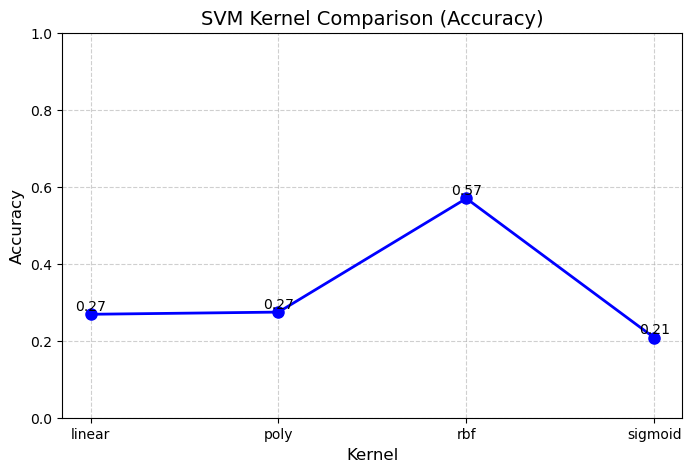

In [45]:
import matplotlib.pyplot as plt

# Convert results to lists
kernels = list(results.keys())
accuracies = list(results.values())

# Plot line graph
plt.figure(figsize=(8,5))
plt.plot(kernels, accuracies, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# Add labels and title
plt.title("SVM Kernel Comparison (Accuracy)", fontsize=14)
plt.xlabel("Kernel", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1)  # keep y-axis between 0 and 1
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate accuracy values on points
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center', fontsize=10)

plt.show()


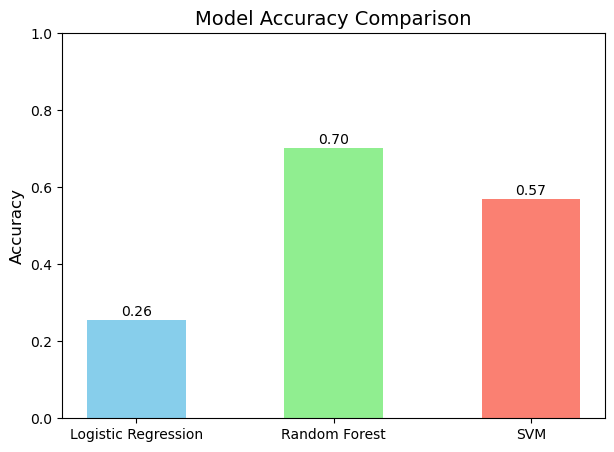

In [46]:
import matplotlib.pyplot as plt

# Suppose you already have the accuracies
logistic_accuracy = accuracy_logistic
rf_accuracy =accuracy_rf
svm_accuracy = accuracy_svm

# Store in dictionary
results = {
    "Logistic Regression": logistic_accuracy,
    "Random Forest": rf_accuracy,
    "SVM": svm_accuracy
}

# Plot bar graph
plt.figure(figsize=(7,5))
plt.bar(results.keys(), results.values(), color=['skyblue','lightgreen','salmon'], width=0.5)

# Add labels and title
plt.title("Model Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0,1)

# Annotate accuracy values on bars
for i, (model, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center', fontsize=10)

plt.show()


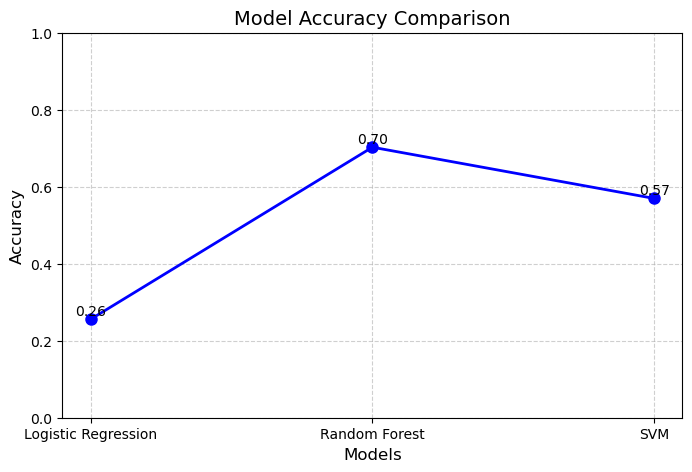

In [47]:
import matplotlib.pyplot as plt

# Example accuracies
logistic_accuracy = accuracy_logistic
rf_accuracy =accuracy_rf
svm_accuracy = accuracy_svm

# Data
models = ["Logistic Regression", "Random Forest", "SVM"]
accuracies = [logistic_accuracy, rf_accuracy, svm_accuracy]

# Plot line graph
plt.figure(figsize=(8,5))
plt.plot(models, accuracies, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# Labels and title
plt.title("Model Accuracy Comparison", fontsize=14)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)

# Annotate values
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center', fontsize=10)

plt.show()


# using cnn

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
DATA_PATH = "Epileptic Seizure Recognition.csv"  
RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SPLIT = 0.2  # used within model.fit for a validation split from training set
BATCH_SIZE = 32
EPOCHS = 50

In [3]:
data = pd.read_csv(DATA_PATH)
print("Raw data shape:", data.shape)
# drop unnamed columns if exist
drop_cols = [c for c in data.columns if str(c).lower().startswith("unnamed")]
if drop_cols:
    data = data.drop(columns=drop_cols, errors="ignore")
print("After drop shape:", data.shape)

# If label column isn't named 'y', attempt to rename common variants
if 'y' not in data.columns:
    for alt in ['label', 'target', 'class', 'y ']:
        if alt in data.columns:
            data = data.rename(columns={alt: 'y'})
            print(f"Renamed {alt} -> 'y'")
            break

# Confirm final columns
print("Columns count:", data.shape[1])
print("First rows:\n", data.head())

Raw data shape: (11500, 180)
After drop shape: (11500, 179)
Columns count: 179
First rows:
     X1   X2   X3   X4   X5   X6   X7   X8   X9  X10  ...  X170  X171  X172  \
0  135  190  229  223  192  125   55   -9  -33  -38  ...   -17   -15   -31   
1  386  382  356  331  320  315  307  272  244  232  ...   164   150   146   
2  -32  -39  -47  -37  -32  -36  -57  -73  -85  -94  ...    57    64    48   
3 -105 -101  -96  -92  -89  -95 -102 -100  -87  -79  ...   -82   -81   -80   
4   -9  -65  -98 -102  -78  -48  -16    0  -21  -59  ...     4     2   -12   

   X173  X174  X175  X176  X177  X178  y  
0   -77  -103  -127  -116   -83   -51  4  
1   152   157   156   154   143   129  1  
2    19   -12   -30   -35   -35   -36  5  
3   -77   -85   -77   -72   -69   -65  5  
4   -32   -41   -65   -83   -89   -73  5  

[5 rows x 179 columns]


In [4]:
# Extract X (2D) and y

X_raw = data.drop(columns=['y']).values.astype(np.float32)
y_raw = data['y'].values
print("X_raw shape (n_samples, n_timesteps):", X_raw.shape)
print("Original labels unique:", np.unique(y_raw))

X_raw shape (n_samples, n_timesteps): (11500, 178)
Original labels unique: [1 2 3 4 5]


In [5]:
# Encode labels to 0..K-1 for sparse_categorical_crossentropy
le = LabelEncoder()
y = le.fit_transform(y_raw)   # results 0..num_classes-1
num_classes = len(le.classes_)
print("Mapped classes:", le.classes_, "-> 0..", num_classes-1)


Mapped classes: [1 2 3 4 5] -> 0.. 4


In [6]:
# FFT function (rfft magnitude)
def compute_fft(X):
    # X: (n_samples, n_timesteps)
    Xf = np.abs(np.fft.rfft(X, axis=1))
    return Xf  # shape (n_samples, n_freqs)

In [7]:
# Resample function (simple linear interpolation) to change timesteps -> new_len
def resample_to_length(X, new_len):
    # X: (n_samples, old_len)
    n, old_len = X.shape
    if old_len == new_len:
        return X.copy()
    old_idx = np.arange(old_len)
    new_idx = np.linspace(0, old_len - 1, new_len)
    # linear interpolation per sample
    X_res = np.empty((n, new_len), dtype=X.dtype)
    for i in range(n):
        X_res[i] = np.interp(new_idx, old_idx, X[i])
    return X_res

In [8]:
# compute FFT
X_fft = compute_fft(X_raw)
print("FFT shape:", X_fft.shape)  # e.g. (n, ~ (timesteps//2 + 1))

# decide common length for CNN timesteps (use FFT length)
timesteps = X_fft.shape[1]
print("Chosen timesteps for CNN (use FFT length):", timesteps)

# resample original time-domain to `timesteps`
X_time_ds = resample_to_length(X_raw, timesteps)
print("Resampled time-domain shape:", X_time_ds.shape)

FFT shape: (11500, 90)
Chosen timesteps for CNN (use FFT length): 90
Resampled time-domain shape: (11500, 90)


In [9]:

#  Stack channels: channel0 = time-domain resampled, channel1 = FFT
# result shape -> (n_samples, timesteps, channels=2)
X_stack = np.stack([X_time_ds, X_fft], axis=-1)  # (n, timesteps, 2)
print("Stacked shape (n, timesteps, channels):", X_stack.shape)

# 7) Scale features: fit scaler on train split only (so split first)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_stack, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

Stacked shape (n, timesteps, channels): (11500, 90, 2)


In [10]:
# For scaling we need a 2D array (samples, features). We'll scale per-channel independently across timesteps:
def scale_3d(X_train, X_val):
    # X_train: (n_train, t, c), X_val: (n_val, t, c)
    n_train, t, c = X_train.shape
    scalers = []
    X_train_scaled = np.empty_like(X_train)
    X_val_scaled = np.empty_like(X_val)
    for ch in range(c):
        s = StandardScaler()
        # reshape to (n_train * t, )
        flat = X_train[:, :, ch].reshape(-1, 1)
        s.fit(flat)
        # transform
        X_train_scaled[:, :, ch] = s.transform(X_train[:, :, ch].reshape(-1, 1)).reshape(n_train, t)
        X_val_scaled[:, :, ch] = s.transform(X_val[:, :, ch].reshape(-1, 1)).reshape(X_val.shape[0], t)
        scalers.append(s)
    return X_train_scaled, X_val_scaled, scalers

In [11]:
# We'll split training into train/val inside model.fit, but scalers must be fit on training-only.
# So create a hold-out validation for scaler fitting (temporary small split)
X_train_for_scaler, X_unused, y_train_for_scaler, _ = train_test_split(
    X_train_full, y_train_full, test_size=VAL_SPLIT, random_state=RANDOM_STATE, stratify=y_train_full
)
# Fit scalers on X_train_for_scaler and transform the full X_train_full and X_test
X_train_scaled, X_train_unused, scalers = scale_3d(X_train_for_scaler, X_train_full)  # careful shapes

In [12]:
# simpler: fit scalers on X_train_full and transform both train and test (acceptable for experiments)
# (If you want strict separation, fit only on X_train_for_scaler and then transform full train/test accordingly)
def fit_scale_all(X_train, X_other_list):
    n_train, t, c = X_train.shape
    scalers = []
    X_train_s = np.empty_like(X_train)
    X_others_s = []
    for ch in range(c):
        s = StandardScaler()
        flat = X_train[:, :, ch].reshape(-1, 1)
        s.fit(flat)
        X_train_s[:, :, ch] = s.transform(X_train[:, :, ch].reshape(-1, 1)).reshape(n_train, t)
        for Xo in X_other_list:
            if len(X_others_s) < len(X_other_list):
                X_others_s.append(np.empty_like(Xo))
        scalers.append(s)
    # now transform the other arrays (test)
    for i, Xo in enumerate(X_other_list):
        n_o = Xo.shape[0]
        transformed = np.empty_like(Xo)
        for ch in range(Xo.shape[2]):
            transformed[:, :, ch] = scalers[ch].transform(Xo[:, :, ch].reshape(-1, 1)).reshape(n_o, t)
        X_others_s[i] = transformed
    return X_train_s, X_others_s, scalers

X_train_s, [X_test_s], scalers = fit_scale_all(X_train_full, [X_test])
print("After scaling shapes:", X_train_s.shape, X_test_s.shape)

After scaling shapes: (9200, 90, 2) (2300, 90, 2)


In [13]:
# Build model (Input used to avoid warnings)
input_shape = (timesteps, X_stack.shape[2])  # (timesteps, channels)
print("Model input shape:", input_shape)

model = Sequential([
    Input(shape=input_shape),
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model input shape: (90, 2)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 90, 64)              │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 90, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 45, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 45, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 45, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 22, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 22, 256)             │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 22, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 11, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2816)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         721,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 847,941 (3.23 MB)

 Trainable params: 847,045 (3.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [14]:
# Callbacks
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-6)

In [15]:
# Train
history = model.fit(
    X_train_s, y_train_full,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[es, rlr],
    verbose=1
)

Epoch 1/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.6337 - loss: 0.8897 - val_accuracy: 0.4033 - val_loss: 1.9979 - learning_rate: 0.0010
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.7035 - loss: 0.6518 - val_accuracy: 0.6582 - val_loss: 0.7066 - learning_rate: 0.0010
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7296 - loss: 0.5798 - val_accuracy: 0.7359 - val_loss: 0.5308 - learning_rate: 0.0010
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7425 - loss: 0.5474 - val_accuracy: 0.7451 - val_loss: 0.5428 - learning_rate: 0.0010
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7625 - loss: 0.5132 - val_accuracy: 0.7582 - val_loss: 0.5172 - learning_rate: 0.0010
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7712 - loss: 0.4822 - val_accuracy: 0.7804 - val_loss: 0.4426 - learning_rate: 0.0010
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7863 - loss: 

In [17]:
# Evaluate
test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}  Loss: {test_loss:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8100 - loss: 0.4007 

Test Accuracy: 0.8100  Loss: 0.4007


72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step  

Confusion Matrix:
[[459   1   0   0   0]
 [  6 222 216   1  15]
 [ 11  68 360   0  21]
 [  1   0   0 407  52]
 [  0   2   9  34 415]]


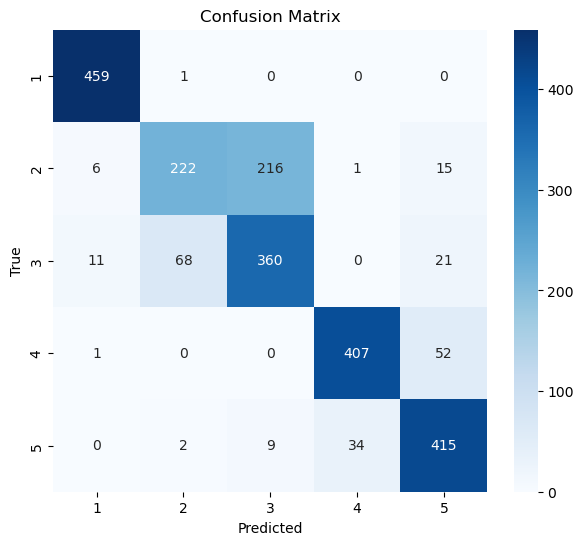


Classification Report:
              precision    recall  f1-score   support

           1       0.96      1.00      0.98       460
           2       0.76      0.48      0.59       460
           3       0.62      0.78      0.69       460
           4       0.92      0.88      0.90       460
           5       0.83      0.90      0.86       460

    accuracy                           0.81      2300
   macro avg       0.82      0.81      0.80      2300
weighted avg       0.82      0.81      0.80      2300



In [18]:
# Predictions + Confusion Matrix + Classification Report
y_pred_proba = model.predict(X_test_s)
y_pred = y_pred_proba.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

In [20]:
# Performance table (accuracy, precision, recall, f1 per class and overall)
prec, rec, f1, sup = precision_recall_fscore_support(y_test, y_pred, average=None)
overall_acc = accuracy_score(y_test, y_pred)
df_perf = pd.DataFrame({
    "class": le.classes_,
    "precision": prec,
    "recall": rec,
    "f1": f1
})
print("\nPer-class performance:")
display(df_perf)
print("\nOverall accuracy:", overall_acc)


Per-class performance:


,class,precision,recall,f1
0,1,0.962264,0.997826,0.979723
1,2,0.757679,0.482609,0.589641
2,3,0.615385,0.782609,0.688995
3,4,0.920814,0.884783,0.902439
4,5,0.825050,0.902174,0.861890



Overall accuracy: 0.81


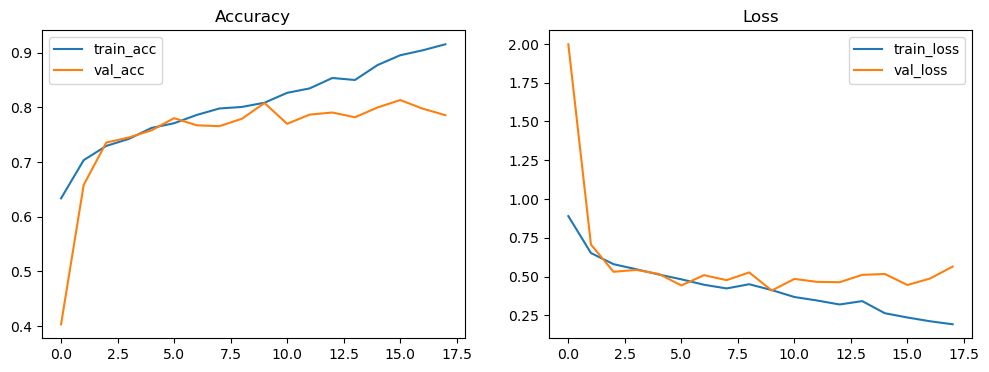

In [21]:
# Plot training curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()



In [22]:
#   BINARY CLASSIFIER FOR EPILEPTIC SEIZURE DETECTION (FFT+CNN)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout


In [34]:
data = pd.read_csv("Epileptic Seizure Recognition.csv")

# Convert to binary:
# class 1 → seizure (1)
# class 2,3,4,5 → non-seizure (0)
data['binary_y'] = (data['y'] == 1).astype(int)

# Extract X and y
X_raw = data.drop(columns=['y','binary_y']).values
y = data['binary_y'].values

In [36]:
# FFT TRANSFORM
def apply_fft(X):
    return np.abs(np.fft.rfft(X, axis=1))

X_fft = apply_fft(X_raw)

# Scale FFT
scaler = StandardScaler()
X_fft = scaler.fit_transform(X_fft)

# Reshape for CNN
X_fft = X_fft.reshape(X_fft.shape[0], X_fft.shape[1], 1)

TypeError: ufunc 'rfft_n_odd' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [25]:
# Extract X (EEG signals)
X_raw = data.drop(columns=["y"]).values   

print("X_raw shape:", X_raw.shape)
print("Binary y shape:", y_binary.shape)

X_raw shape: (11500, 178)
Binary y shape: (11500,)


In [26]:
# APPLY FFT (Convert time → frequency domain)

def apply_fft(X):
    """Apply FFT to each sample (row-wise)."""
    return np.abs(np.fft.rfft(X, axis=1))

X_fft = apply_fft(X_raw)
print("FFT shape (before scaling):", X_fft.shape)  

FFT shape (before scaling): (11500, 90)


In [27]:
# SCALING
scaler = StandardScaler()
X_fft_scaled = scaler.fit_transform(X_fft)
print("FFT shape (scaled):", X_fft_scaled.shape)

# Reshape for CNN
X_fft_scaled = X_fft_scaled.reshape(X_fft_scaled.shape[0], X_fft_scaled.shape[1], 1)
print("Final CNN input shape:", X_fft_scaled.shape)


FFT shape (scaled): (11500, 90)
Final CNN input shape: (11500, 90, 1)


In [28]:
# TRAIN/TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_fft_scaled, y_binary, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_binary
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (9200, 90, 1)  Test: (2300, 90, 1)


In [29]:
# BUILD CNN MODEL

model = Sequential([
    Input(shape=(X_train.shape[1], 1)),

    Conv1D(64, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(256, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(1, activation='sigmoid')   # Binary output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)                    │ (None, 88, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 88, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 44, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 42, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 42, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 21, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 19, 256)             │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 19, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_5 (MaxPooling1D)       │ (None, 9, 256)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 420,481 (1.60 MB)

 Trainable params: 419,585 (1.60 MB)

 Non-trainable params: 896 (3.50 KB)

In [30]:
# TRAIN THE MODEL

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7505 - loss: 0.5039 - val_accuracy: 0.7283 - val_loss: 0.5106
Epoch 2/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7912 - loss: 0.3968 - val_accuracy: 0.8005 - val_loss: 0.3849
Epoch 3/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7981 - loss: 0.3841 - val_accuracy: 0.8038 - val_loss: 0.3662
Epoch 4/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8069 - loss: 0.3624 - val_accuracy: 0.8049 - val_loss: 0.3588
Epoch 5/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8234 - loss: 0.3387 - val_accuracy: 0.8038 - val_loss: 0.3644
Epoch 6/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8304 - loss: 0.3224 - val_accuracy: 0.8087 - val_loss: 0.3635
Epoch 7/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8399 - loss: 0.3099 - val_accuracy: 0.8065 - val_loss: 0.3544
Epoch 8/25
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8586 - loss: 0.2782 - val_acc

In [31]:
# EVALUATE
loss, acc = model.evaluate(X_test, y_test)
print("\n Test Accuracy:", acc)

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8057 - loss: 0.7765 

 Test Accuracy: 0.8056522011756897


72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step  

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1380
           1       0.75      0.77      0.76       920

    accuracy                           0.81      2300
   macro avg       0.80      0.80      0.80      2300
weighted avg       0.81      0.81      0.81      2300



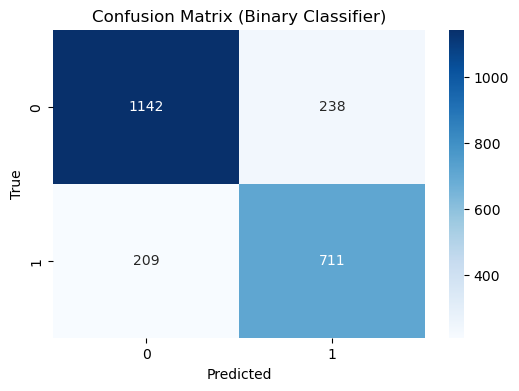

In [32]:
# CONFUSION MATRIX & CLASSIFICATION REPORT
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix (Binary Classifier)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

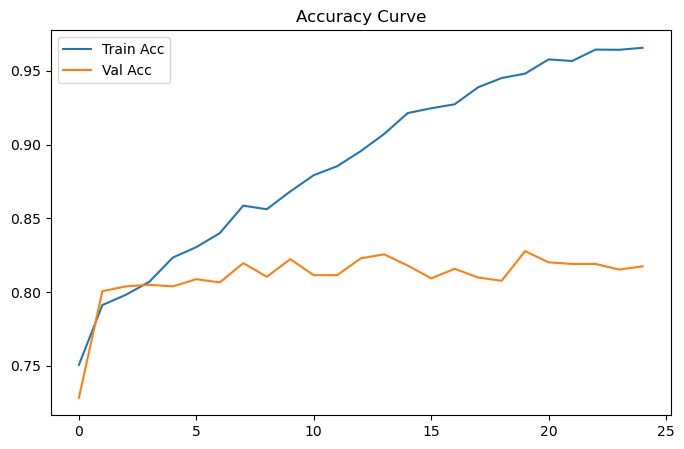

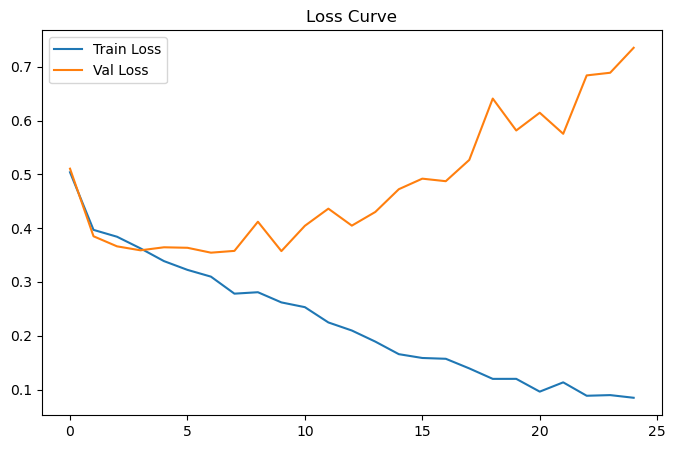

In [33]:
# PLOT TRAINING CURVES
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()
